# Notebook description

In this notebook, we performed **cross validation** on a *LSTM* (Long Short Term Memories) based recurrent network with a convolutional layer in front.

The network is composed of *two recurrent layers*, each one including 64 recurrent units.

The input of the recurrent network is the result of a 32 channels *convolutional network* with a kernel of size 3.

The output of the recurrent network is fed to a *dense layer* composed of 32 neurons.

The loss function that is minimized during the training of the model is weighted based on the class frequency in the dataset.

---



# Google Drive connection

In [ ]:
from google.colab import drive
drive.mount("/gdrive")
current_dir = "/gdrive/My\\ Drive/challengeAN2DL"
%cd $current_dir

Drive already mounted at /gdrive; to attempt to forcibly remount, call drive.mount("/gdrive", force_remount=True).
/gdrive/.shortcut-targets-by-id/1FBs0a25Urpk8cZPLeXuOnI8nzY3Yx1TA/challengeAN2DL


# Import libraries

In [ ]:
# Set seed for reproducibility
SEED = 128347

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.8.0+cu126
Device: cuda


# Data loading

In [ ]:
# DATASET NAMES
DATASET_NAME_TRAINING = "an2dl2526c1/pirate_pain_train.csv"
DATASET_NAME_LABELS = "an2dl2526c1/pirate_pain_train_labels.csv"
DATASET_NAME_TEST = "an2dl2526c1/pirate_pain_test.csv"

df = pd.read_csv(DATASET_NAME_TRAINING)
labels = pd.read_csv(DATASET_NAME_LABELS)
df_test = pd.read_csv(DATASET_NAME_TEST)

# Data preprocessing

In [ ]:
# Drop Outliers
drop_indeces = [16, 21, 137, 152, 225, 357, 381, 418, 439, 444, 511, 513, 521, 566, 628, 657,
                44, 338, 465,
                92, 300]

df = df[~df["sample_index"].isin(drop_indeces)]
labels = labels[~labels["sample_index"].isin(drop_indeces)]

# Drop constant features
df = df.drop('joint_30', axis=1)
df_test = df_test.drop('joint_30', axis=1)

# Drop redundant features
df = df.drop('n_legs', axis=1)
df_test = df_test.drop('n_legs', axis=1)
df = df.drop('n_hands', axis=1)
df_test = df_test.drop('n_hands', axis=1)
df = df.drop('n_eyes', axis=1)
df_test = df_test.drop('n_eyes', axis=1)

# Transformation to float32

# pain_survey
for index in range(4):
    i = index + 1
    column = 'pain_survey_' + str(i)
    df[column] = df[column].astype(np.float32)
    df_test[column] = df_test[column].astype(np.float32)

# joint
for index in range(30):
    column = 'joint_' + str(index).zfill(2)
    df[column] = df[column].astype(np.float32)
    df_test[column] = df_test[column].astype(np.float32)

In [ ]:
# SPLITTING

# add labels to train set
df = df.merge(labels, on='sample_index', how='left')
df = df.rename(columns={'label': 'pain_level'})

# Features of the training set
scale_columns = df.columns[2:-1].tolist()

# Sequence building

In [ ]:
WINDOW_SIZE = 64
STRIDE = 16

In [ ]:
# Define a function to build sequences from the dataset
def build_sequences(df, validation, window=40, stride=40):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialise lists to store sequences and their corresponding labels
    dataset = []
    labels = []

    # Iterate over unique IDs in the DataFrame
    for id in df['sample_index'].unique():
        # Extract sensor data for the current ID
        temp = df[df['sample_index'] == id][scale_columns].values

        # Retrieve the activity label for the current ID
        label = df[df['sample_index'] == id]['pain_level'].values[0]

        # Calculate padding length to ensure full windows
        padding_len = window - len(temp) % window

        # Create zero padding and concatenate with the data
        padding = np.zeros((padding_len, len(scale_columns)), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Build feature windows and associate them with labels
        idx = 0

        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            labels.append(label)
            idx += stride

    # Convert lists to numpy arrays for further processing
    dataset = np.array(dataset)
    labels = np.array(labels)

    return dataset, labels

In [ ]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 64

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

# Model building

In [ ]:
def recurrent_summary(model, input_size):
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [ ]:

class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, or GRU) with optional Conv1d frontend.
    Uses the last hidden state for classification (as in your original code).
    """

    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',           # 'RNN', 'LSTM', or 'GRU'
            bidirectional=False,
            dropout_rate=0.2,         # RNN dropout (between layers if num_layers > 1)
            dense_hidden_size=None,   # Dense layer size (optional)
            dense_dropout=0.2,        # Dense layer dropout
            # --- Conv frontend options ---
            use_conv=False,
            conv_out_channels=64,
            conv_kernel_size=5,
            conv_stride=1,
            conv_padding=None,        # if None -> "same" padding for stride=1
            conv_dropout=0.1,
            conv_batch_norm=True
    ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        self.use_conv = use_conv

        # ---------- Optional Conv1d frontend ----------
        # Input comes as (batch, seq_len, input_size)
        # Conv1d expects (batch, channels, seq_len), so channels = input_size.
        if self.use_conv:
            if conv_padding is None:
                # "Same-ish" padding for stride=1
                # This keeps seq_len unchanged when stride=1.
                conv_padding = (conv_kernel_size - 1) // 2

            self.conv = nn.Conv1d(
                in_channels=input_size,
                out_channels=conv_out_channels,
                kernel_size=conv_kernel_size,
                stride=conv_stride,
                padding=conv_padding,
                bias=not conv_batch_norm
            )

            self.conv_bn = nn.BatchNorm1d(conv_out_channels) if conv_batch_norm else None
            self.conv_activation = nn.ReLU()
            self.conv_dropout = nn.Dropout(conv_dropout)

            rnn_input_size = conv_out_channels
        else:
            rnn_input_size = input_size

        # ---------- RNN core ----------
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout inside RNN only applies between stacked layers
        rnn_dropout = dropout_rate if num_layers > 1 else 0.0

        self.rnn = rnn_module(
            input_size=rnn_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,        # (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=rnn_dropout
        )

        rnn_out_dim = hidden_size * (2 if bidirectional else 1)

        # -----Dense layer-------
        self.has_fc = dense_hidden_size is not None
        if self.has_fc:
          self.fc = nn.Sequential(
              nn.Linear(rnn_out_dim, dense_hidden_size),
              nn.ReLU(),
              nn.Dropout(dense_dropout)
          )
          classifier_input_dim = dense_hidden_size
        else:
          self.fc = nn.Identity()
          classifier_input_dim = rnn_out_dim

        self.classifier = nn.Linear(classifier_input_dim, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # ----- Optional Conv frontend -----
        if self.use_conv:
            # (B, T, F) -> (B, F, T)
            x = x.transpose(1, 2)

            x = self.conv(x)
            if self.conv_bn is not None:
                x = self.conv_bn(x)
            x = self.conv_activation(x)
            x = self.conv_dropout(x)

            # Back to (B, T, C) for RNN
            x = x.transpose(1, 2)

        # ----- RNN -----
        rnn_out, hidden = self.rnn(x)

        # LSTM: hidden is (h_n, c_n); we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # (num_layers, 2, batch, hidden)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)
            # last layer forward + backward
            hidden_to_dense = torch.cat(
                [hidden[-1, 0, :, :], hidden[-1, 1, :, :]],
                dim=1
            )  # (batch, hidden * 2)
        else:
            # last layer
            hidden_to_dense = hidden[-1]  # (batch, hidden)

        dense_to_classify = self.fc(hidden_to_dense)

        logits = self.classifier(dense_to_classify)
        return logits


# Network and training hyperparameters

In [ ]:
experiment_name = "CV_convolutional"
rnn_type = "LSTM"

# Training configuration
LEARNING_RATE = 5e-3
EPOCHS = 300
PATIENCE = 30

CLIP_GRADIENT = False

# Architecture
HIDDEN_LAYERS = 1        # Hidden layers
HIDDEN_SIZE = 64         # Neurons per layer

# DENSE
DENSE_SIZE = 32
DENSE_DROPOUT = 0.2

# Regularisation
DROPOUT_RATE = 0.2        # Dropout probability
L1_LAMBDA = 0             # L1 penalty
L2_LAMBDA = 0.001         # L2 penalty

#CONV layer
CONV_OUT_CHANNELS = 64
CONV_KERNEL_SIZE = 7
CONV_STRIDE = 1
CONV_PADDING = None      # auto "same" for stride=1
CONV_DROPOUT = 0.3


class_counts = torch.tensor([77., 14., 9.])
class_weights = class_counts.sum() / class_counts  # inverse frequency-style
class_weights = class_weights / class_weights.mean()
class_weights = class_weights.to(device)

# Weighted Loss + Label smoothing
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

# CROSS VALIDATION FOLDS
K = 5

# Model Training

In [ ]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0, clip_gradient=CLIP_GRADIENT):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()


        # Gradient clipping (on unscaled grads)

        if clip_gradient:
          scaler.unscale_(optimizer)
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)

        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", scheduler=None):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # SCHEDULER
        # Step the scheduler if provided (typically after validation)
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_f1)
            else:
                scheduler.step()


        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/proveMarci/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/proveMarci/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/proveMarci/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

# Cross Validation

In [ ]:
def k_shuffle_split_cross_validation_round_rnn(df, train_split_ratio, epochs, criterion, device,
                            k, batch_size, hidden_layers, hidden_size, learning_rate, dropout_rate,
                            bidirectional, rnn_type, dense_hidden_size, dense_dropout, use_conv, conv_out_channels, conv_kernel_size,
                            conv_stride, conv_padding, conv_dropout, conv_batch_norm,
                            l1_lambda=0, l2_lambda=0, patience=0, window_size=WINDOW_SIZE, stride=STRIDE,
                            evaluation_metric="val_f1", mode='max', restore_best_weights=True, writer=None,
                            verbose=10, seed=SEED, experiment_name=""):


    # The (merged) dataframe must contain features (2 to end - 1) and pain_level (last column)
    # Initialise containers for results across all splits

    fold_losses = {}
    fold_metrics = {}
    best_scores = {}

    # Retrieve number of input features and number of classes

    # scale_columns = ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4',
    #                  'n_legs', 'n_hands', 'n_eyes', joint00, ..., joint29]

    scale_columns = df.columns[2:-1].tolist()
    in_features = len(scale_columns)
    num_classes = len(df['pain_level'].unique())

    rnn_model = RecurrentClassifier(
        input_size=in_features,
        hidden_size=hidden_size,
        num_layers=hidden_layers,
        num_classes=num_classes,
        dropout_rate=dropout_rate,
        bidirectional=bidirectional,
        rnn_type=rnn_type,
        dense_hidden_size=dense_hidden_size,
        dense_dropout=dense_dropout,
        use_conv=use_conv,
        conv_out_channels=conv_out_channels,
        conv_kernel_size=conv_kernel_size,
        conv_stride=conv_stride,
        conv_padding=conv_padding,
        conv_dropout=conv_dropout,
        conv_batch_norm=conv_batch_norm
    ).to(device)

    # Store initial weights to reset model for each split
    initial_state = copy.deepcopy(rnn_model.state_dict())

    # Iterate through K random splits
    for split_idx in range(k):

        if verbose > 0:
            print(f"Split {split_idx+1}/{k}")
        # Create random split

        unique_pirates = df['sample_index'].unique()
        random.seed(seed + split_idx) # Different shuffle for every index
        random.shuffle(unique_pirates)

        N_TRAIN_PIRATES = int(len(unique_pirates) * train_split_ratio)
        N_VAL_PIRATES = len(unique_pirates) - N_TRAIN_PIRATES

        train_pirates = unique_pirates[:N_TRAIN_PIRATES]
        val_pirates = unique_pirates[N_TRAIN_PIRATES:]

        df_train = df[df['sample_index'].isin(train_pirates)].copy()
        df_val = df[df['sample_index'].isin(val_pirates)].copy()

        label_mapping = {
            'no_pain': 0,
            'low_pain': 1,
            'high_pain': 2
        }

        df_train['pain_level'] = df_train['pain_level'].map(label_mapping)
        df_val['pain_level'] = df_val['pain_level'].map(label_mapping)

        # Calculate the minimum and maximum values from the training data only
        mins = df_train[scale_columns].min()
        maxs = df_train[scale_columns].max()

        # Apply normalisation to the specified columns in all datasets
        for column in scale_columns:
            # Normalise the training set
            df_train[column] = (df_train[column] - mins[column]) / (maxs[column] - mins[column])

            # Normalise the validation set
            df_val[column] = (df_val[column] - mins[column]) / (maxs[column] - mins[column])


        # Build sequences
        X_train, y_train = build_sequences(df_train, False, window_size, stride)
        X_val, y_val = build_sequences(df_val, True, window_size, stride)

        # Create PyTorch datasets
        train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
        val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))

        # Create data loaders
        train_loader = make_loader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
        val_loader   = make_loader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

        # Reset model to initial weights for fair comparison across splits
        rnn_model.load_state_dict(initial_state)

        optimizer = torch.optim.AdamW(rnn_model.parameters(), lr=learning_rate, weight_decay=l2_lambda)

        # Enable mixed precision training for GPU acceleration
        scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

        # Create directory for model checkpoints

        os.makedirs(f"models/proveMarci/{experiment_name}", exist_ok=True)


        # scheduler
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',                         # Monitor a metric that should be minimized (RMSE)
            factor=0.4,                         # Factor by which the learning rate will be reduced
            patience=max(10,PATIENCE//2),       # Number of epochs with no improvement after which learning rate will be reduced
            min_lr=1e-5                         # Minimum learning rate
        )


        # Train model on current split
        rnn_model, training_history = fit(
            model=rnn_model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            writer=writer,
            patience=patience,
            verbose=verbose,
            experiment_name=experiment_name+"/split_"+str(split_idx),
            l1_lambda=l1_lambda,
            evaluation_metric=evaluation_metric,
            mode=mode,
            restore_best_weights=restore_best_weights,
            scheduler=scheduler
        )

        # Store results for this split
        fold_losses[f"split_{split_idx}"] = training_history['val_loss']
        fold_metrics[f"split_{split_idx}"] = training_history['val_f1']
        best_scores[f"split_{split_idx}"] = max(training_history['val_f1'])

    # Compute mean and standard deviation of best scores across splits
    best_scores["mean"] = np.mean([best_scores[k] for k in best_scores.keys() if k.startswith("split_")])
    best_scores["std"] = np.std([best_scores[k] for k in best_scores.keys() if k.startswith("split_")])

    if verbose > 0:
        print(f"Best score: {best_scores['mean']:.4f}±{best_scores['std']:.4f}")

    return fold_losses, fold_metrics, best_scores

In [ ]:
# CALL TO CROSS-VALIDATION
%%time
# Execute K-fold cross-validation with baseline configuration
losses, metrics, best_scores = k_shuffle_split_cross_validation_round_rnn(
    df=df,
    train_split_ratio=0.8,
    epochs=EPOCHS,
    criterion=criterion,
    device=device,
    k=K,
    batch_size=BATCH_SIZE,
    hidden_layers=HIDDEN_LAYERS,
    hidden_size=HIDDEN_SIZE,
    learning_rate=LEARNING_RATE,
    dropout_rate=DROPOUT_RATE,
    dense_hidden_size=DENSE_SIZE,
    dense_dropout=DENSE_DROPOUT,
    use_conv=True,
    conv_out_channels=CONV_OUT_CHANNELS,
    conv_kernel_size=CONV_KERNEL_SIZE,
    conv_stride=CONV_STRIDE,
    conv_padding=CONV_PADDING,
    conv_dropout=CONV_DROPOUT,
    conv_batch_norm=True,
    l1_lambda=L1_LAMBDA,
    l2_lambda=L2_LAMBDA,
    verbose=1,
    patience=PATIENCE,
    seed=SEED,
    experiment_name=experiment_name,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    rnn_type=rnn_type,
    bidirectional=True
)

Split 1/5
Training 300 epochs...
Epoch   1/300 | Train: Loss=0.9827, F1 Score=0.6467 | Val: Loss=1.1065, F1 Score=0.6135
Epoch   2/300 | Train: Loss=0.7504, F1 Score=0.8200 | Val: Loss=1.0255, F1 Score=0.7226
Epoch   3/300 | Train: Loss=0.6986, F1 Score=0.8517 | Val: Loss=1.8024, F1 Score=0.4998
Epoch   4/300 | Train: Loss=0.6477, F1 Score=0.8413 | Val: Loss=2.1513, F1 Score=0.0396
Epoch   5/300 | Train: Loss=0.6180, F1 Score=0.8678 | Val: Loss=0.9464, F1 Score=0.8354
Epoch   6/300 | Train: Loss=0.5467, F1 Score=0.8872 | Val: Loss=0.9654, F1 Score=0.8192
Epoch   7/300 | Train: Loss=0.5295, F1 Score=0.9008 | Val: Loss=0.7813, F1 Score=0.8997
Epoch   8/300 | Train: Loss=0.5087, F1 Score=0.8989 | Val: Loss=1.0173, F1 Score=0.7385
Epoch   9/300 | Train: Loss=0.4781, F1 Score=0.9215 | Val: Loss=0.8273, F1 Score=0.8623
Epoch  10/300 | Train: Loss=0.4506, F1 Score=0.9311 | Val: Loss=0.9621, F1 Score=0.8449
Epoch  11/300 | Train: Loss=0.4541, F1 Score=0.9368 | Val: Loss=1.0157, F1 Score=0.8735

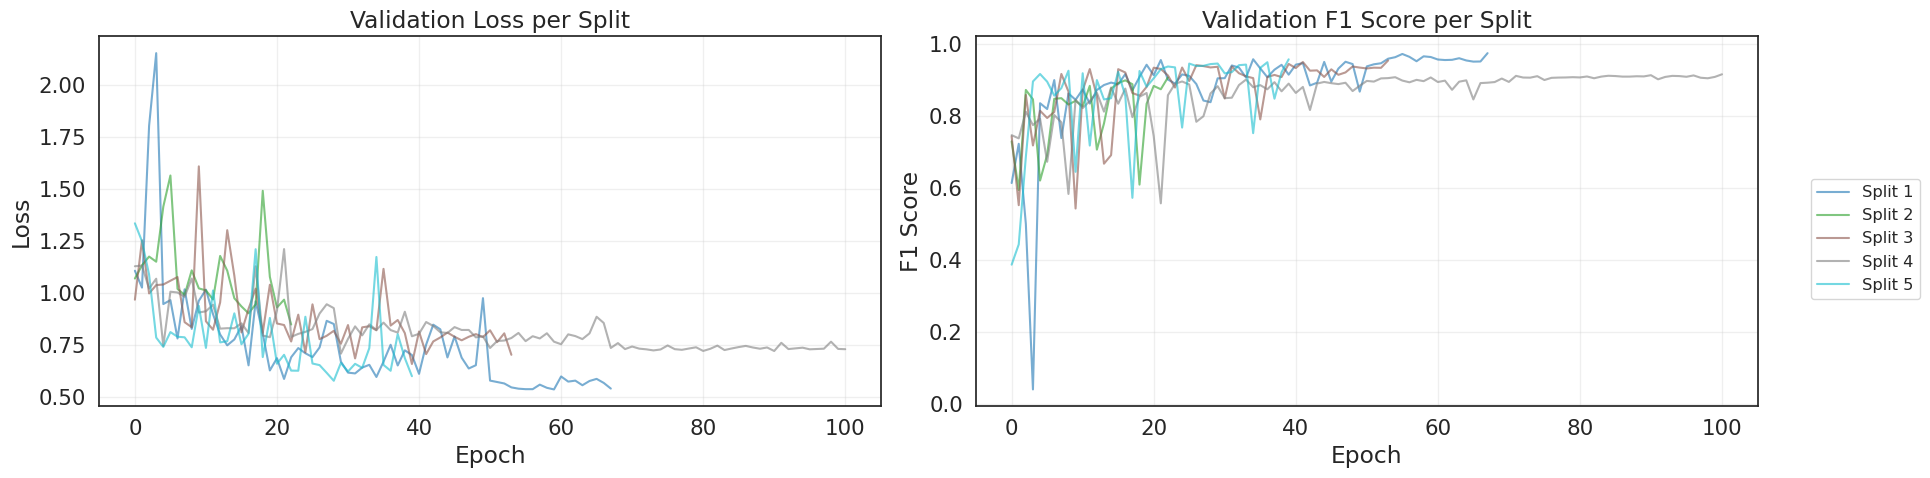

In [ ]:
# @title Plot History
# Create figure with two subplots sharing x axis
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5), sharex=True)

# Color palette for K splits
colors = plt.cm.get_cmap('tab10', K)

# Plot validation loss for each split
for split in range(K):
    axes[0].plot(losses[f'split_{split}'][:-PATIENCE], label=f'Split {split+1}',
                 color=colors(split), alpha=0.6)
axes[0].set_title('Validation Loss per Split')
axes[0].set_ylabel('Loss')
axes[0].set_xlabel('Epoch')
axes[0].grid(alpha=0.3)

# Plot validation F1 score for each split
for split in range(K):
    axes[1].plot(metrics[f'split_{split}'][:-PATIENCE], label=f'Split {split+1}',
                 color=colors(split), alpha=0.6)
axes[1].set_title('Validation F1 Score per Split')
axes[1].set_ylabel('F1 Score')
axes[1].set_xlabel('Epoch')
axes[1].grid(alpha=0.3)

# Add shared legend on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=0.975)
plt.show()